<a href="https://colab.research.google.com/github/Ishini01/HerbVision/blob/main/Implementation1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"awankaranathunga","key":"2f9bdc0560de2fdfc977965febb68b6e"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the dataset
!kaggle datasets download -d ahilaprem/mepco-tropic-leaf

# Unzip the downloaded file
!unzip mepco-tropic-leaf.zip -d mepco_tropic_leaf

# Check extracted files
!ls mepco_tropic_leaf

Streaming output truncated to the last 5000 lines.
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/Database/Green Chireta.zip/014_18.jpg  
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/Database/Green Chireta.zip/014_19.jpg  
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/Database/Green Chireta.zip/014_2.jpg  
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/Database/Green Chireta.zip/014_20.jpg  
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/Database/Green Chireta.zip/014_21.jpg  
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/Database/Green Chireta.zip/014_22.jpg  
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/Database/Green Chireta.zip/014_23.jpg  
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/Database/Green Chireta.zip/014_24.jpg  
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/Database/Green Chireta.zip/014_25.jpg  
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/Database/Green Chireta.zip/014_26.jpg  
  inflating: mepco_tropic_leaf/MepcoTropicLeaf-V1/

In [ ]:
import os

data_path = "/content/mepco_tropic_leaf"
print(os.listdir(data_path))

['MepcoTropicLeaf-V1', 'Spinach']


In [ ]:
print(os.listdir("/content/mepco_tropic_leaf/MepcoTropicLeaf-V1"))

['Database']


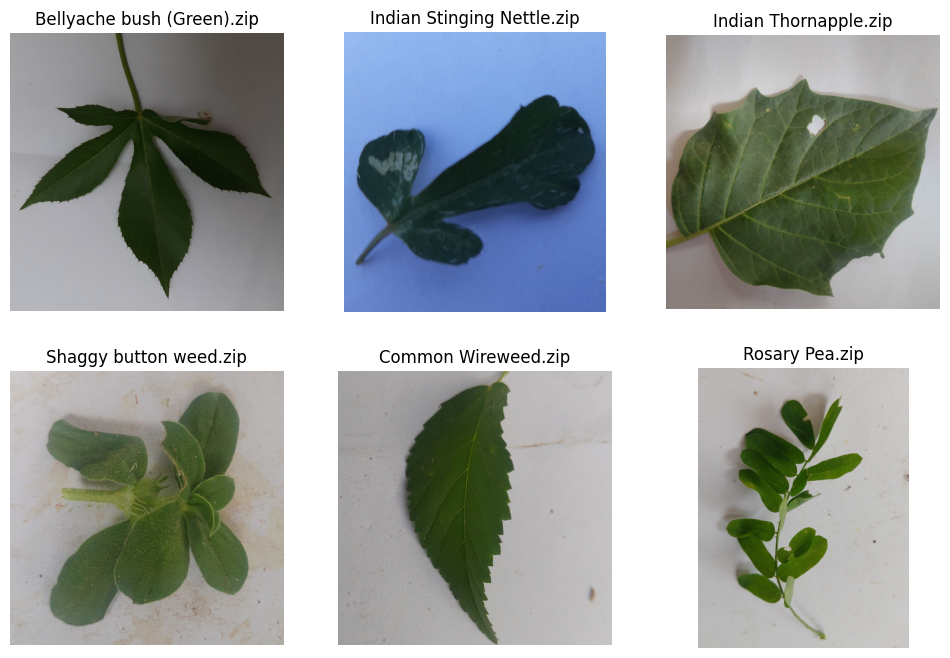

In [ ]:
plt.figure(figsize=(12,8))

for i, class_name in enumerate(class_folders[:6]):  # first 6 classes

    images = os.listdir(os.path.join(data_path, class_name))
    image_path = os.path.join(data_path, class_name, images[0])

    img = Image.open(image_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
import os

data_path = "/content/mepco_tropic_leaf/MepcoTropicLeaf-V1/Database"

class_folders = [f for f in os.listdir(data_path)
                 if os.path.isdir(os.path.join(data_path, f))]

print("Total Classes:", len(class_folders))

total_images = 0
for folder in class_folders:
    total_images += len(os.listdir(os.path.join(data_path, folder)))

print("Total Images:", total_images)

Total Classes: 50
Total Images: 3777


In [ ]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

# Create training dataset (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Create validation dataset (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Normalize images
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 3777 files belonging to 50 classes.
Using 3022 files for training.
Found 3777 files belonging to 50 classes.
Using 755 files for validation.


In [ ]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,175,410 (42.63 MB)

 Trainable params: 11,175,410 (42.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 352s 4s/step - accuracy: 0.0637 - loss: 3.8068 - val_accuracy: 0.2119 - val_loss: 2.8382
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 372s 4s/step - accuracy: 0.3337 - loss: 2.4037 - val_accuracy: 0.4291 - val_loss: 2.0836
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 356s 4s/step - accuracy: 0.5841 - loss: 1.4976 - val_accuracy: 0.5126 - val_loss: 1.7176
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 388s 4s/step - accuracy: 0.7098 - loss: 0.9628 - val_accuracy: 0.5510 - val_loss: 1.8893
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.8467 - loss: 0.5476 - val_accuracy: 0.5536 - val_loss: 2.0133
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 369s 4s/step - accuracy: 0.8940 - loss: 0.3633 - val_accuracy: 0.6265 - val_loss: 1.7372
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 366s 4s/step - accuracy: 0.9427 - loss: 0.1947 - val_accuracy: 0.6146 - val_loss: 2.1054
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.9583 - loss: 0.1354 - val_accuracy: 0.6079 - v

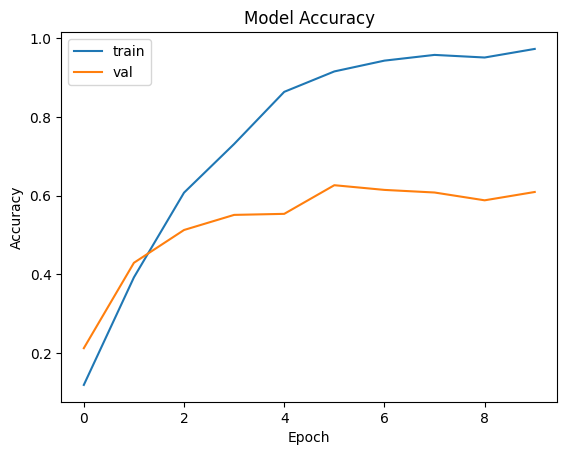

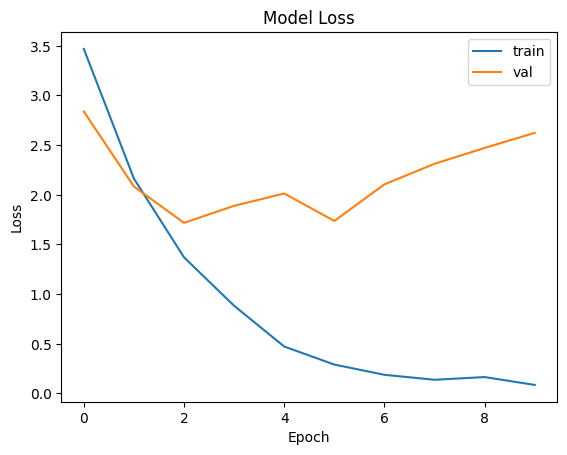

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6081 - loss: 2.4847
Validation Accuracy: 0.6092715263366699


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 936ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 885ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 928ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 937ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step


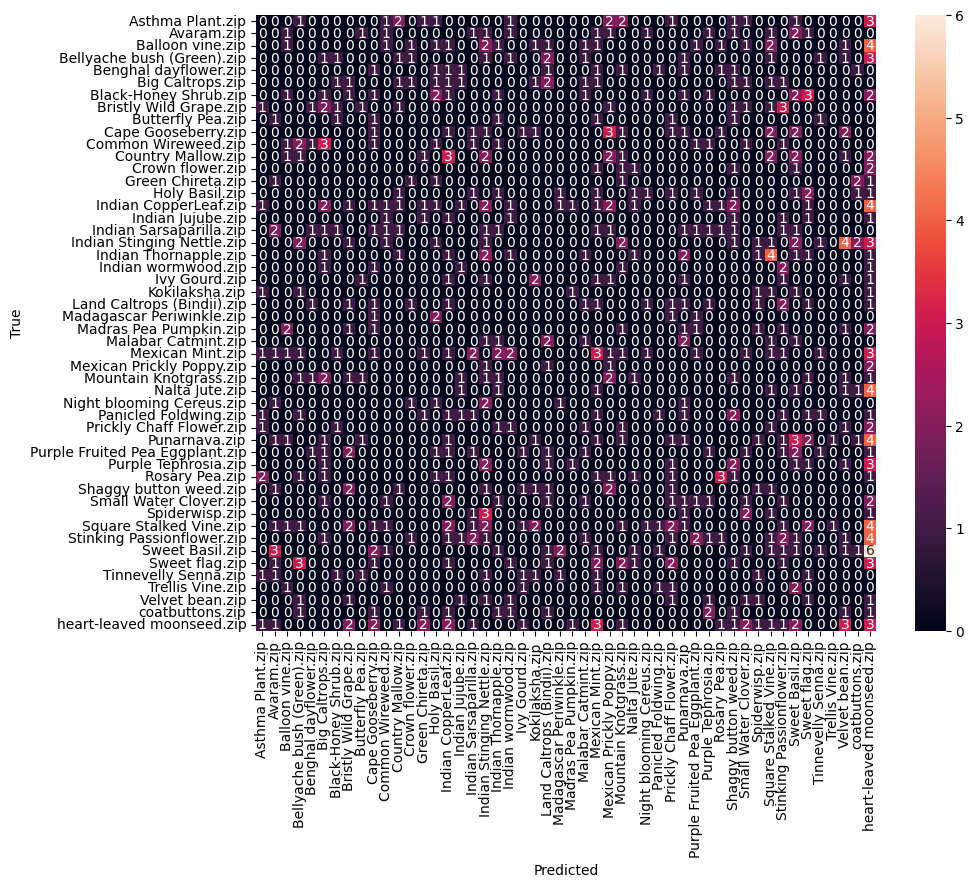

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = np.concatenate([np.argmax(model.predict(x), axis=1) for x, y in val_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


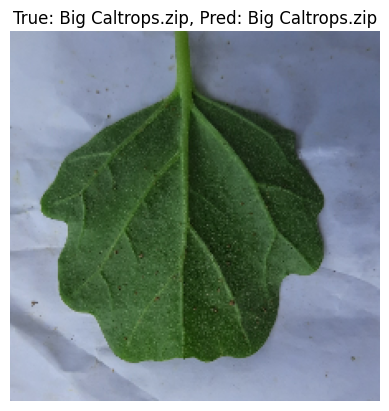

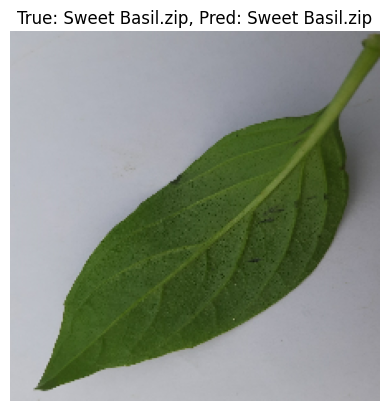

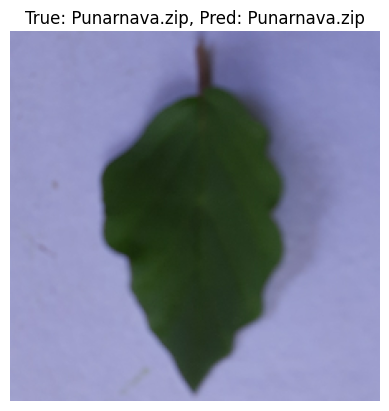

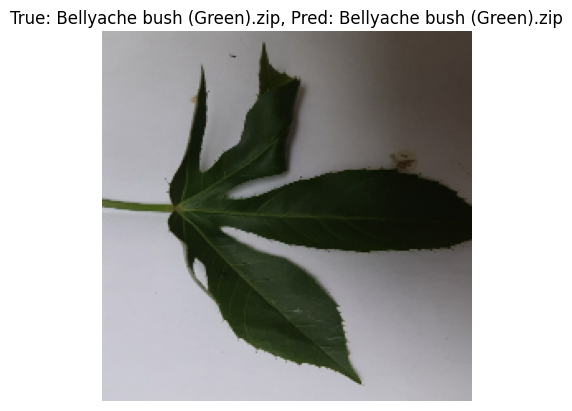

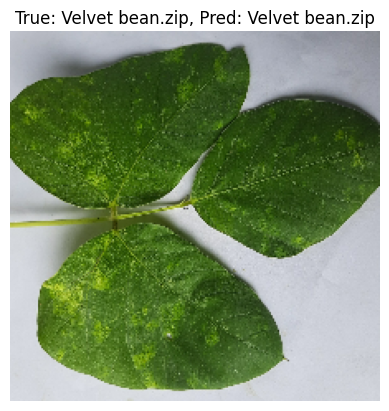

In [ ]:
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    for i in range(5):
        plt.imshow(images[i].numpy())
        plt.title(f"True: {class_names[labels[i]]}, Pred: {class_names[np.argmax(preds[i])]}")
        plt.axis('off')
        plt.show()

In [ ]:
model.save("/content/mepco_leaf_model.h5")

In [ ]:
from google.colab import files
files.download("/content/mepco_leaf_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mucuna-pruriens-leaves.jpg to mucuna-pruriens-leaves (1).jpg


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image

# Replace 'my_leaf.jpg' with your uploaded filename
img_path = list(uploaded.keys())[0]

# Load the image
img = Image.open(img_path)

# Resize to the same size used for training
img = img.resize((224, 224))

# Convert to array and normalize
img_array = np.array(img)/255.0

# Add batch dimension (model expects shape: [1, 224, 224, 3])
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("/content/mepco_leaf_model.h5")

In [ ]:
# Predict class probabilities
pred_probs = model.predict(img_array)

# Get predicted class index
pred_index = np.argmax(pred_probs)

# Map index to class label
pred_class = class_names[pred_index]

print("Predicted Class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Predicted Class: Velvet bean.zip


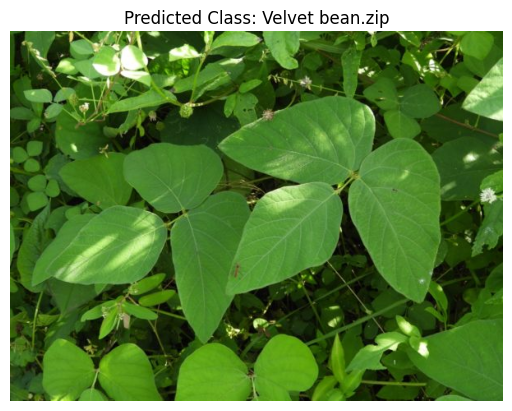

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(Image.open(img_path))
plt.title(f"Predicted Class: {pred_class}")
plt.axis("off")
plt.show()